In [1]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import  load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model= "gemini-2.5-flash")

In [4]:
class ChatState(MessagesState):
    summary : str

In [5]:
def chat_node(state:ChatState):
    messages = []
    if state['summary']:
        messages.append(
            {
                "role":"system",
                "content":f"Conversation Summary: \n{state['summary']}"
            }
        )
    messages.extend(state["messages"])
    print(messages) 
    response = model.invoke(messages)
    return {"messages" :[response]}

In [6]:
def summarize_conversation(state:ChatState):
    existing_summary = state['summary']
    
    #building summarization prompt for the llm
    if existing_summary:
        prompt = (
            f" Existing Summary : \n {state['summary']}\n\n"
            "Extend summary using the new conversation above."
        )
    else:
        prompt = "summarize the conversation above"
        
    messages_for_summary = state['messages'] + [HumanMessage(content=prompt)]
    response = model.invoke(messages_for_summary)
    
    #trimming keeping only last two messages and rest we are summarizing here
    messages_to_remove = state['messages'][:-2]
    
    messages_after_trimming = [RemoveMessage(id=m.id) for m in messages_to_remove]
    return {"messages": messages_after_trimming,"summary":response.content}

In [7]:
def should_summarize(state:ChatState):
    return len(state['messages']) > 6

In [10]:
builder = StateGraph(ChatState)

builder.add_node('chat',chat_node)
builder.add_node('summarize',summarize_conversation)

builder.add_edge(START,'chat')
builder.add_conditional_edges(
    'chat',
    should_summarize,
    {
        True:"summarize",
        False:"__end__"
    }
)
builder.add_edge('summarize',END)


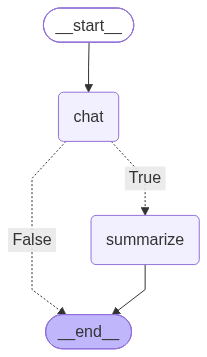

In [11]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

In [13]:
def run_tern(text:str):
    output = graph.invoke({"messages":[HumanMessage(content=text)],"summary":""},config=config)
    return output

In [14]:
#method to give the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n************************************** STATE *********************************")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])#showing only 80 characters of the generated message

In [15]:
#function call
run_tern('NeuroPlasticity')
show_state()

[HumanMessage(content='NeuroPlasticity', additional_kwargs={}, response_metadata={}, id='76beabfb-15f4-47d3-92ae-295274664af6')]

************************************** STATE *********************************
summary: 
num_messages: 2
messages:
- HumanMessage : NeuroPlasticity
- AIMessage : Neuroplasticity, often referred to as **brain plasticity**, is the remarkable ab


In [16]:
run_tern('How is it related to AI')
show_state()

[HumanMessage(content='NeuroPlasticity', additional_kwargs={}, response_metadata={}, id='76beabfb-15f4-47d3-92ae-295274664af6'), AIMessage(content='Neuroplasticity, often referred to as **brain plasticity**, is the remarkable ability of the brain to change and adapt its structure and function throughout an individual\'s life. It\'s not a static organ; it\'s dynamic, constantly reorganizing itself in response to experience, learning, injury, and environmental demands.\n\nHere\'s a breakdown of what that means:\n\n1.  **Structural Changes:** The brain can physically alter its structure. This includes:\n    *   **Synaptic Plasticity:** The strengthening or weakening of connections (synapses) between neurons. "Neurons that fire together, wire together" is a common adage reflecting this. New synapses can also form, and old ones can be pruned away.\n    *   **Dendritic Branching:** Neurons can grow new dendrites (the "antennae" that receive signals), increasing their capacity to connect with

In [17]:
run_tern('What is its importance in Human Life')
show_state()

[HumanMessage(content='NeuroPlasticity', additional_kwargs={}, response_metadata={}, id='76beabfb-15f4-47d3-92ae-295274664af6'), AIMessage(content='Neuroplasticity, often referred to as **brain plasticity**, is the remarkable ability of the brain to change and adapt its structure and function throughout an individual\'s life. It\'s not a static organ; it\'s dynamic, constantly reorganizing itself in response to experience, learning, injury, and environmental demands.\n\nHere\'s a breakdown of what that means:\n\n1.  **Structural Changes:** The brain can physically alter its structure. This includes:\n    *   **Synaptic Plasticity:** The strengthening or weakening of connections (synapses) between neurons. "Neurons that fire together, wire together" is a common adage reflecting this. New synapses can also form, and old ones can be pruned away.\n    *   **Dendritic Branching:** Neurons can grow new dendrites (the "antennae" that receive signals), increasing their capacity to connect with

In [18]:
run_tern('Explain according to a physchologist? how can we help ')
show_state()

[HumanMessage(content='NeuroPlasticity', additional_kwargs={}, response_metadata={}, id='76beabfb-15f4-47d3-92ae-295274664af6'), AIMessage(content='Neuroplasticity, often referred to as **brain plasticity**, is the remarkable ability of the brain to change and adapt its structure and function throughout an individual\'s life. It\'s not a static organ; it\'s dynamic, constantly reorganizing itself in response to experience, learning, injury, and environmental demands.\n\nHere\'s a breakdown of what that means:\n\n1.  **Structural Changes:** The brain can physically alter its structure. This includes:\n    *   **Synaptic Plasticity:** The strengthening or weakening of connections (synapses) between neurons. "Neurons that fire together, wire together" is a common adage reflecting this. New synapses can also form, and old ones can be pruned away.\n    *   **Dendritic Branching:** Neurons can grow new dendrites (the "antennae" that receive signals), increasing their capacity to connect with